<div style="position:absolute; top:0; left:0; width:1280px; height:720px; margin:0; padding:0; overflow:hidden;">
  <img src="bandiera_Oly_highres.jpg" style="width:1280px; height:720px; object-fit:cover; display:block;">
  <h1.copertina style="position:absolute; top:30px; right:64px; color:white; font-family:Cambria,serif; text-align:right; line-height:1.2; font-size:64px; margin:0;">
    <span style="display:block; padding-right:200px;">IL VANTAGGIO DI</span>
    <span style="display:block;">GIOCARE IN CASA</span>
  </h1>
</div>

<div style="position:absolute; top:0; left:0; width:1280px; height:720px; display:flex; flex-direction:column; justify-content:center; padding:60px 80px; box-sizing:border-box; gap:60px;">
  <div>
    <h4 style="font-size:35px; font-weight:bold; margin:0 0 12px 0;">FINALITÀ DELL'ANALISI STATISTICA</h4>
    <ul style="font-size:25px; line-height:1.7; margin:0;">
      <li>Determinare se la nazione ospitante i Giochi Olimpici ottiene più medaglie rispetto alle altre edizioni</li>
      <li>Individuare i fattori che possono influenzare questo eventuale vantaggio olimpico</li>
    </ul>
  </div>
  <div>
    <h4 style="font-size:35px; font-weight:bold; margin:0 0 12px 0;">PERCHÉ QUEST'ANALISI?</h4>
    <ul style="font-size:25px; line-height:1.7; margin:0;">
      <li>Interesse personale e passione per le competizioni sportive</li>
      <li>Successo della delegazione italiana alle Olimpiadi: Milano Cortina 2026</li>
    </ul>
  </div>
</div>

## STILI

### Importazione dei moduli necessari

In [151]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp


In [152]:
mpl.rcParams['font.size'] = 14
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.grid.axis'] = 'y'
mpl.rcParams['grid.linestyle'] = '--'
mpl.rcParams['grid.alpha'] = 0.7

### Importazione del dataset di riferimento

In [153]:
df=pd.read_csv("athlete_events.csv")

### Aggiunta colonna "HostCountry" e colonna "HostNOC"

In [154]:
host_data=[
# SUMMER GAMES
(1896, "Summer", "GRE", "Greece"),
(1900, "Summer", "FRA", "France"),
(1904, "Summer", "USA", "United States"),
(1908, "Summer", "GBR", "United Kingdom"),
(1912, "Summer", "SWE", "Sweden"),
(1920, "Summer", "BEL", "Belgium"),
(1924, "Summer", "FRA", "France"),
(1928, "Summer", "NED", "Netherlands"),
(1932, "Summer", "USA", "United States"),
(1936, "Summer", "GER", "Germany"),
(1948, "Summer", "GBR", "United Kingdom"),
(1952, "Summer", "FIN", "Finland"),
(1956, "Summer", "AUS", "Australia"),
(1960, "Summer", "ITA", "Italy"),
(1964, "Summer", "JPN", "Japan"),
(1968, "Summer", "MEX", "Mexico"),
(1972, "Summer", "GER", "Germany"),
(1976, "Summer", "CAN", "Canada"),
(1980, "Summer", "URS", "Soviet Union"),
(1984, "Summer", "USA", "United States"),
(1988, "Summer", "KOR", "South Korea"),
(1992, "Summer", "ESP", "Spain"),
(1996, "Summer", "USA", "United States"),
(2000, "Summer", "AUS", "Australia"),
(2004, "Summer", "GRE", "Greece"),
(2008, "Summer", "CHN", "China"),
(2012, "Summer", "GBR", "United Kingdom"),
(2016, "Summer", "BRA", "Brazil"),

# WINTER GAMES
(1924, "Winter", "FRA", "France"),
(1928, "Winter", "SUI", "Switzerland"),
(1932, "Winter", "USA", "United States"),
(1936, "Winter", "GER", "Germany"),
(1948, "Winter", "SUI", "Switzerland"),
(1952, "Winter", "NOR", "Norway"),
(1956, "Winter", "ITA", "Italy"),
(1960, "Winter", "USA", "United States"),
(1964, "Winter", "AUT", "Austria"),
(1968, "Winter", "FRA", "France"),
(1972, "Winter", "JPN", "Japan"),
(1976, "Winter", "AUT", "Austria"),
(1980, "Winter", "USA", "United States"),
(1984, "Winter", "YUG", "Yugoslavia"),
(1988, "Winter", "CAN", "Canada"),
(1992, "Winter", "FRA", "France"),
(1994, "Winter", "NOR", "Norway"),
(1998, "Winter", "JPN", "Japan"),
(2002, "Winter", "USA", "United States"),
(2006, "Winter", "ITA", "Italy"),
(2010, "Winter", "CAN", "Canada"),
(2014, "Winter", "RUS", "Russia"),
(2018, "Winter", "KOR", "South Korea"),
]

host_df=pd.DataFrame(host_data, columns=["Year", "Season", "HostNOC", "HostCountry"])

In [155]:
df=df.merge(host_df, on=["Year", "Season"], how="left")

### Riordino delle colonne per visualizzazione più coerente

In [156]:
df=df[["ID", "Year", "Season", "HostCountry", "HostNOC", "City", "Name", "Sport", "Event", "Team", "NOC", "Medal"]]

## ESEMPIO DI DATI PRESENTI

In [157]:
df.head(5).style.set_properties(**{
    'padding': '10px',
    'text-align': 'center',
    'white-space': 'normal',
    'font-size': 'clamp(12px, 1.2vw, 20px)'
})

,ID,Year,Season,HostCountry,HostNOC,City,Name,Sport,Event,Team,NOC,Medal
0,1,1992,Summer,Spain,ESP,Barcelona,A Dijiang,Basketball,Basketball Men's Basketball,China,CHN,nan
1,2,2012,Summer,United Kingdom,GBR,London,A Lamusi,Judo,Judo Men's Extra-Lightweight,China,CHN,nan
2,3,1920,Summer,Belgium,BEL,Antwerpen,Gunnar Nielsen Aaby,Football,Football Men's Football,Denmark,DEN,nan
3,4,1900,Summer,France,FRA,Paris,Edgar Lindenau Aabye,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Denmark/Sweden,DEN,Gold
4,5,1988,Winter,Canada,CAN,Calgary,Christine Jacoba Aaftink,Speed Skating,Speed Skating Women's 500 metres,Netherlands,NED,nan


### Creazione dataset con solo gli atleti medagliati per allegerire il dataset nel momento in cui si andranno a fare analisi su questi atleti

In [158]:
df_medals=df[df["Medal"].notna()]
df_medals=df_medals.drop_duplicates(subset=["Year", "Season", "NOC", "Event", "Medal"])

## NUMERO OLIMPIADI OSPITATE

In [159]:
host_df=pd.DataFrame(host_data, columns=["Year", "Season", "HostNOC", "HostCountry"])
host_counts=host_df.groupby(["HostCountry", "Season"]).size().unstack(fill_value=0)
host_counts["Total"]=host_counts["Summer"]+host_counts["Winter"]
host_counts=host_counts.sort_values("Total", ascending=False)

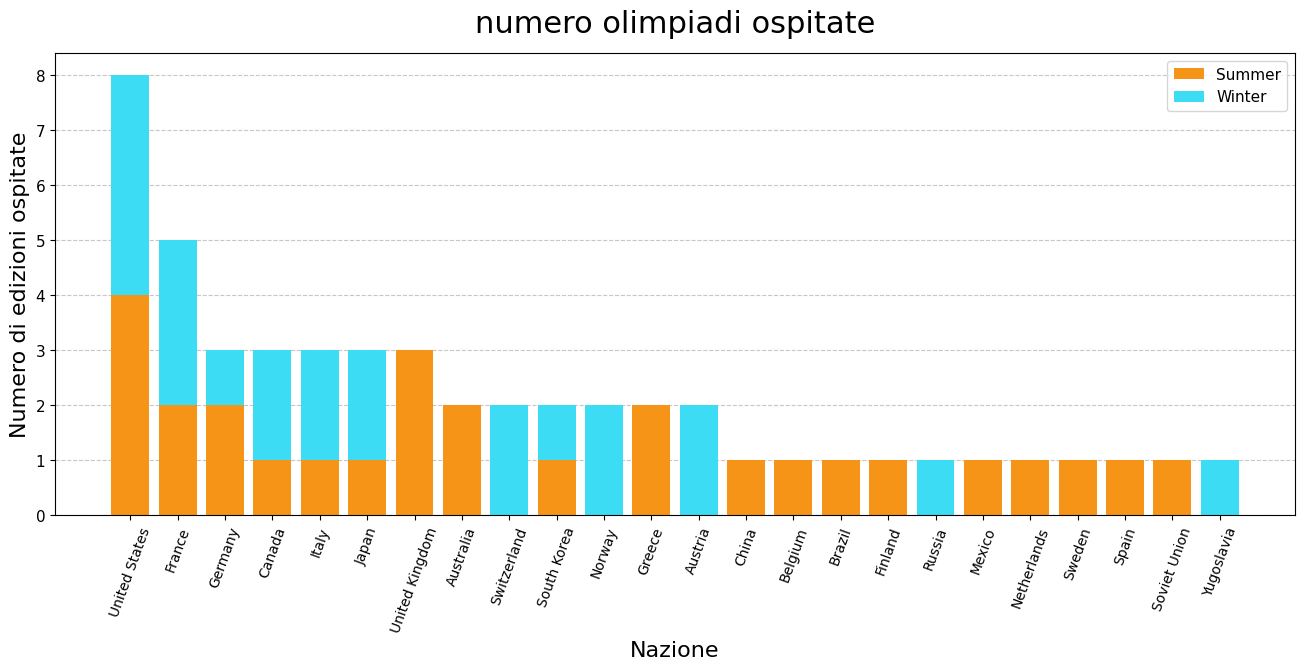

In [160]:
plt.figure(figsize=(16, 6))
plt.bar(host_counts.index, host_counts["Summer"], color="#F59416", label="Summer")
plt.bar(host_counts.index, host_counts["Winter"], bottom=host_counts["Summer"], color="#3CDCF5", label="Winter")
plt.ylabel("Numero di edizioni ospitate")
plt.xlabel("Nazione")
plt.xticks(rotation=70, fontsize=10)
plt.gca().set_axisbelow(True)
plt.yticks(fontsize=11)
plt.legend(fontsize=11)
plt.title("numero olimpiadi ospitate", fontsize=22, pad=15)
plt.savefig("Numero_Oly_ospitate.png", dpi=150, bbox_inches="tight")
plt.show()


# OSPITARE LE OLIMPIADI FA AUMENTARE IL NUMERO DI MEDAGLIE DELLA NAZIONE?

In [161]:
df_medals.loc[:,"IsHost"]=df_medals["NOC"]==df_medals["HostNOC"]
medal_count_year_Host=df_medals.groupby(["Year", "NOC", "IsHost", "Season"]).size().reset_index(name="MedalCount")

## CONFRONTO TRA TUTTI I PAESI

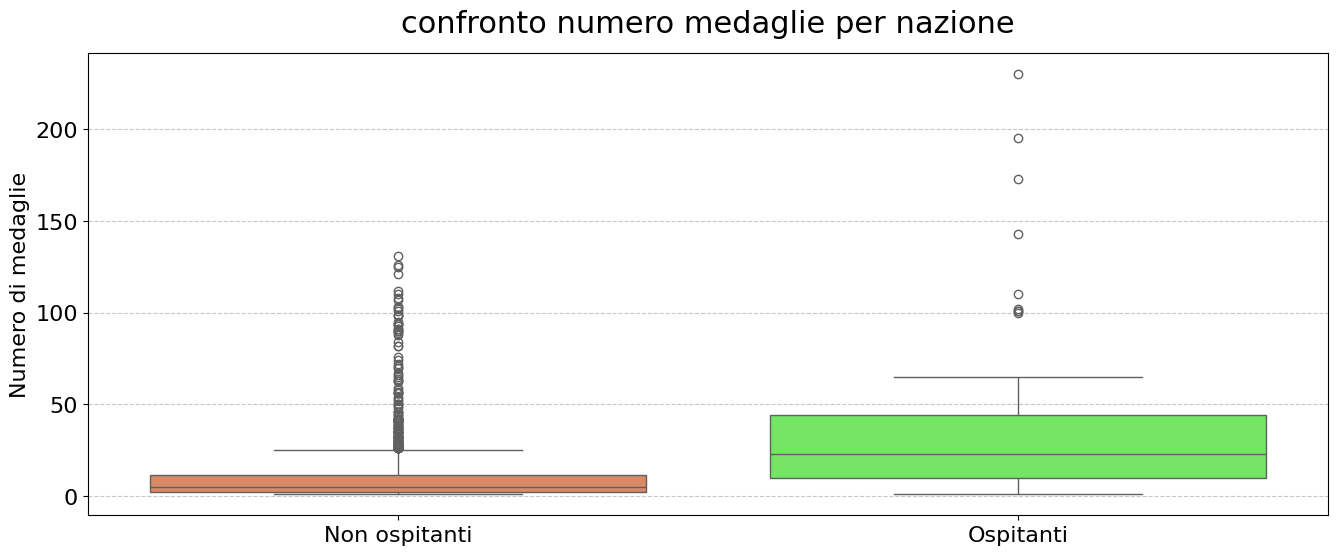

In [162]:
plt.figure(figsize=(16,6))
sns.boxplot(x="IsHost", y="MedalCount", hue="IsHost", data=medal_count_year_Host, palette={False: "#EB8354", True: "#64FA50"}, legend=False)
plt.xticks([0,1], ["Non ospitanti", "Ospitanti"])
plt.xlabel("")
plt.ylabel("Numero di medaglie")
plt.title("confronto numero medaglie per nazione", fontsize=22, pad=15)
plt.savefig("BoxPlot_numero_medaglie_per_nazione.png", dpi=150, bbox_inches="tight")
plt.show()


## CONFRONTO TRA I PAESI CHE HANNO OSPITATO LE OLIMPIADI ALMENO UNA VOLTA

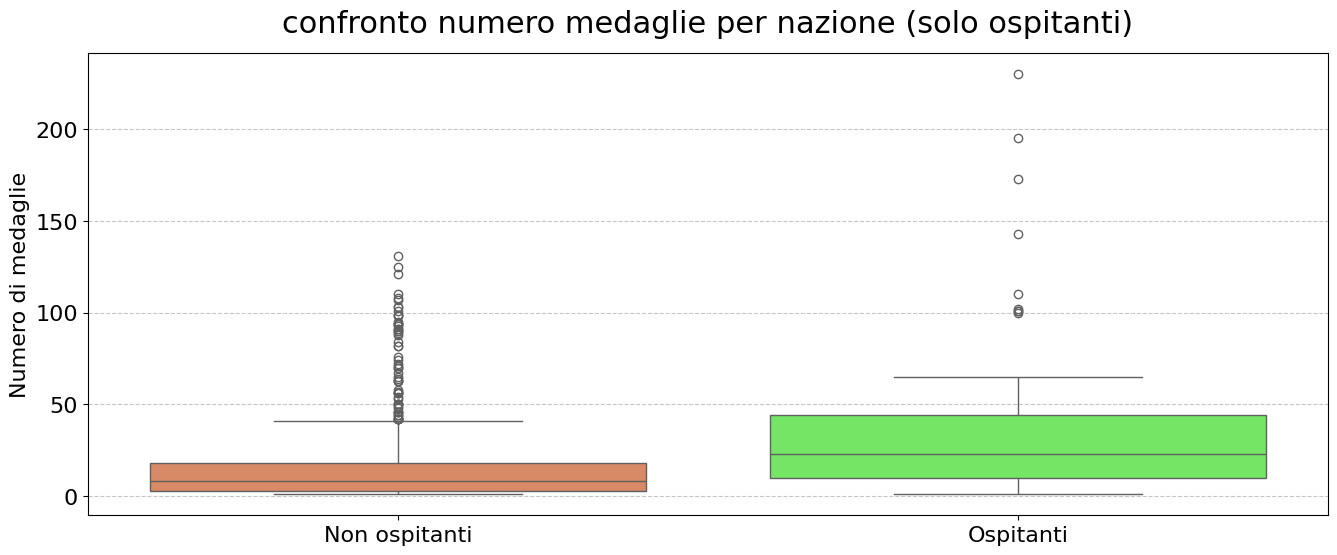

In [163]:
hosts=host_df["HostNOC"].unique()
medal_count_host_only=medal_count_year_Host[medal_count_year_Host["NOC"].isin(hosts)]

plt.figure(figsize=(16,6))
sns.boxplot(x="IsHost", y="MedalCount", hue="IsHost", data=medal_count_host_only, palette={False: "#EB8354", True: "#64FA50"}, legend=False)
plt.xticks([0,1], ["Non ospitanti", "Ospitanti"])
plt.xlabel("")
plt.ylabel("Numero di medaglie")
plt.title("confronto numero medaglie per nazione (solo ospitanti)", fontsize=22, pad=15)
plt.savefig("BoxPlot_numero_medaglie_per_nazione_solo_host.png", bbox_inches="tight")
plt.show()


## MEDAGLIE MEDIE PER NAZIONE: OSPITANTE VS NON OSPITANTE

In [164]:
avg_host=medal_count_host_only[medal_count_host_only["IsHost"]==True].groupby("NOC")["MedalCount"].mean()
avg_nonhost=medal_count_host_only[medal_count_host_only["IsHost"]==False].groupby("NOC")["MedalCount"].mean()

df_avg=pd.DataFrame({"Ospitante": avg_host.values, "Non ospitante": avg_nonhost[avg_host.index].values}, index=avg_host.index)
df_avg["Diff"]=df_avg["Ospitante"] - df_avg["Non ospitante"]
df_avg=df_avg.sort_values("Diff", ascending=False)

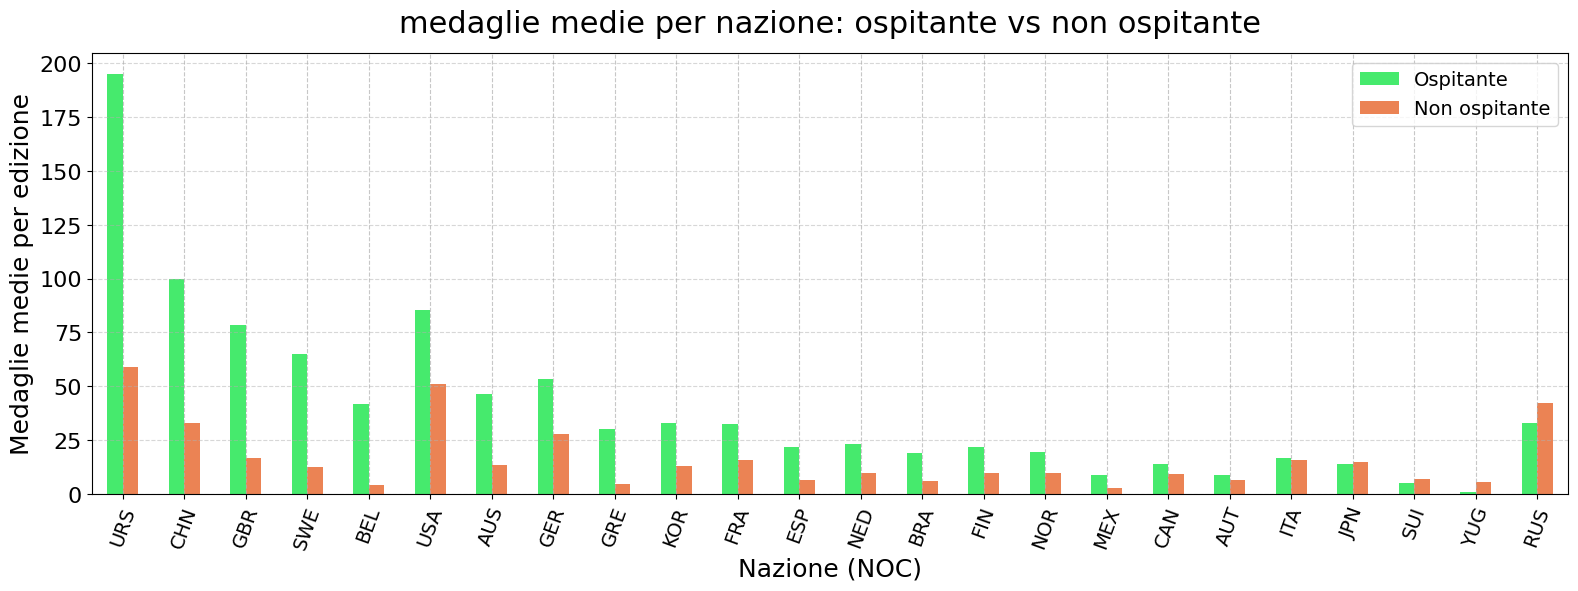

In [165]:
df_avg[["Ospitante", "Non ospitante"]].plot.bar(figsize=(16,6), color=["#46EA6D", "#EB8354"])
plt.ylabel("Medaglie medie per edizione", fontsize=18)
plt.xlabel("Nazione (NOC)", fontsize=18)
plt.grid(axis="y", alpha=0.5)
plt.xticks(fontsize=14, rotation=70)
plt.legend(fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.title("medaglie medie per nazione: ospitante vs non ospitante", fontsize=22, pad=15)
plt.savefig("Numero_medio_medaglie_host_e_nonHost.png", dpi=150, bbox_inches="tight")
plt.show()


## CORRELAZIONE MEDAGLIE - OSPITANTE VS NON OSPITANTE

In [166]:
host_medals=medal_count_host_only[medal_count_host_only["IsHost"]==True]["MedalCount"]
nonhost_medals=medal_count_host_only[medal_count_host_only["IsHost"]==False]["MedalCount"]

t_stat, p_value=sp.stats.ttest_ind(host_medals, nonhost_medals, equal_var=False)
print(f"p-value: {p_value:.5f}")

p-value: 0.00063


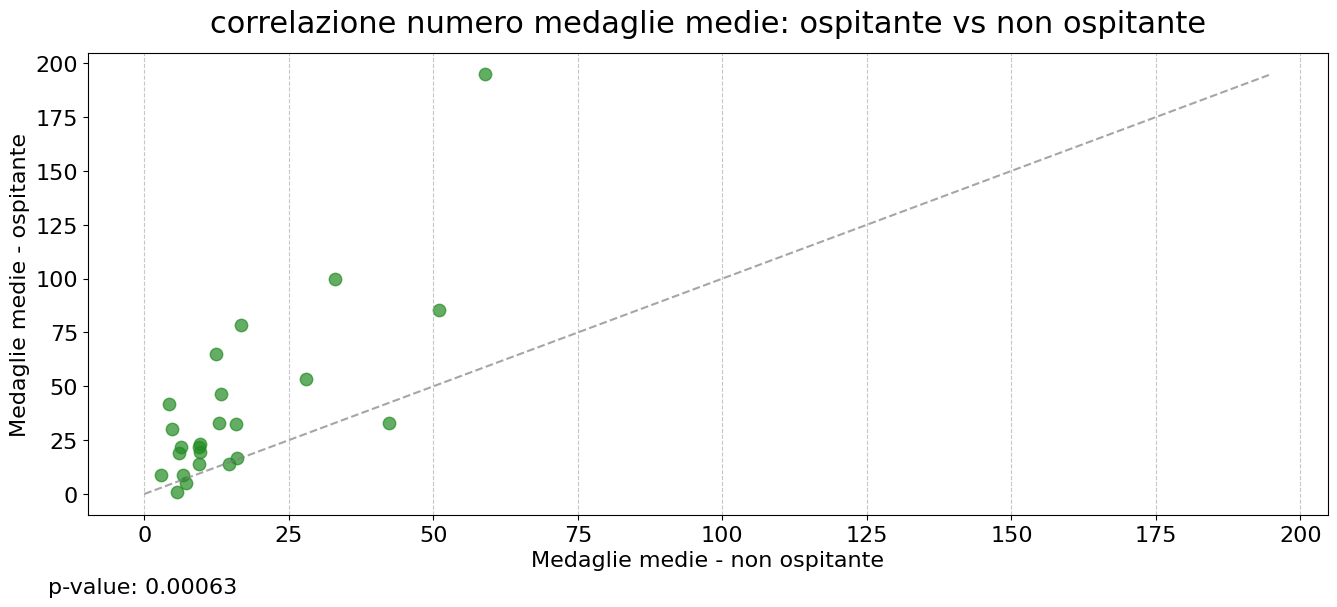

In [167]:
plt.figure(figsize=(16,6))
plt.scatter(df_avg["Non ospitante"], df_avg["Ospitante"], color="#228b22", s=80, alpha=0.7)

max_val=max(df_avg["Ospitante"].max(), df_avg["Non ospitante"].max())
plt.plot([0, max_val], [0, max_val], linestyle="--", color="gray", alpha=0.7)

plt.xlabel("Medaglie medie - non ospitante")
plt.ylabel("Medaglie medie - ospitante")
plt.grid(axis="both")
plt.figtext(0.1, -0.02, f"p-value: {p_value:.5f}", fontsize=16)
plt.title("correlazione numero medaglie medie: ospitante vs non ospitante", fontsize=22, pad=15)
plt.savefig("Medaglie_medie_nazioni_host_quando_host_e_nonHost.png", dpi=150, bbox_inches="tight")
plt.show()


#  DA DOVE ARRIVA QUESTO VANTAGGIO?

## NUMERO MAGGIORE DI ATLETI?

In [168]:
df_athletes=df.drop_duplicates(subset=["Year", "Season", "NOC", "Name"])
athletes_count=df_athletes.groupby(["Year", "Season", "NOC"]).size().reset_index(name="NumAthletes")

In [169]:
df_medals_total=df[df["Medal"].notna()].drop_duplicates(subset=["Year", "Season", "NOC", "Event", "Medal"])
medals_count=df_medals_total.groupby(["Year", "Season", "NOC"]).size().reset_index(name="NumMedals")
num_athletes_medals=athletes_count.merge(medals_count, on=["Year", "Season", "NOC"], how="left")
num_athletes_medals["NumMedals"]=num_athletes_medals["NumMedals"].fillna(0)
num_athletes_medals=num_athletes_medals.merge(host_df, on=["Year", "Season"], how="left")
num_athletes_medals["IsHost"]=num_athletes_medals["NOC"]==num_athletes_medals["HostNOC"]
num_athletes_medals["MedalsPerAthlete"]=num_athletes_medals["NumMedals"]/num_athletes_medals["NumAthletes"]



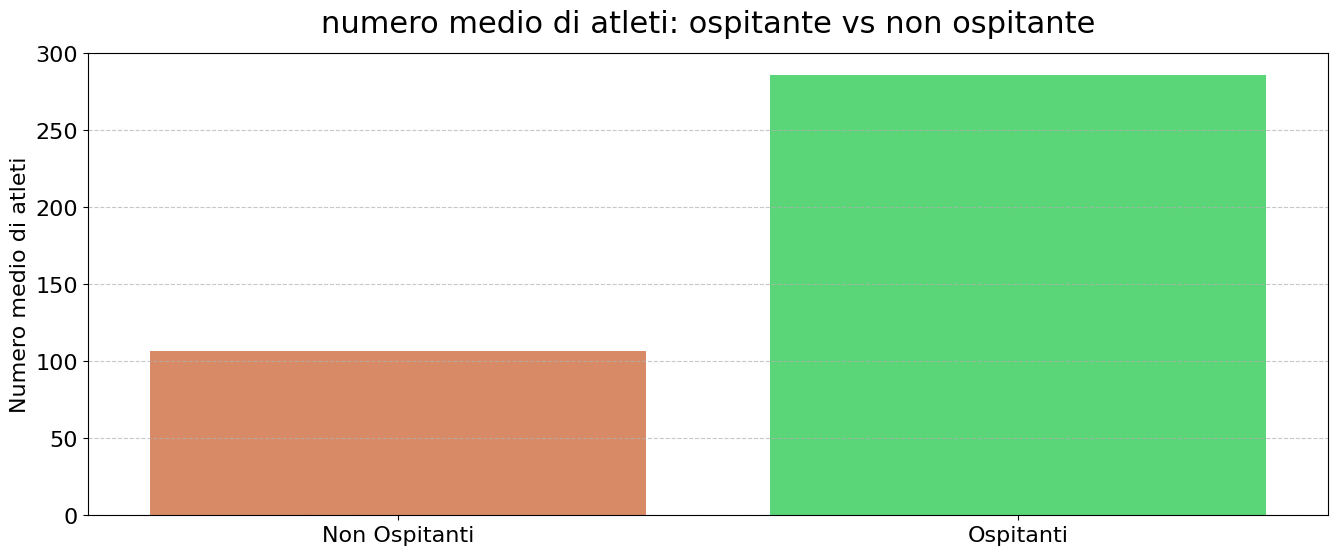

In [170]:
num_athletes_medals_NOC_host=num_athletes_medals[num_athletes_medals["NOC"].isin(hosts)]

avg_athletes=num_athletes_medals_NOC_host.groupby("IsHost")["NumAthletes"].mean().reset_index()

plt.figure(figsize=(16,6))
sns.barplot(x="IsHost", y="NumAthletes", hue="IsHost", data=avg_athletes, palette=["#EB8354", "#46EA6D"], legend=False)
plt.xticks([0,1], ["Non Ospitanti", "Ospitanti"])
plt.ylabel("Numero medio di atleti")
plt.xlabel("")
plt.title("numero medio di atleti: ospitante vs non ospitante", fontsize=22, pad=15)
plt.savefig("Numero_atleti_host_e_nonHost.png", dpi=150, bbox_inches="tight")
plt.show()


## QUANTO VANTAGGIO E' SPIEGATO DAL NUMERO DI ATLETI?

In [171]:
coeff_ang, intercetta, r_value, _, _=sp.stats.linregress(num_athletes_medals_NOC_host["NumAthletes"], num_athletes_medals_NOC_host["NumMedals"])
print(f"R^2: {r_value**2:.3f}")

R^2: 0.636


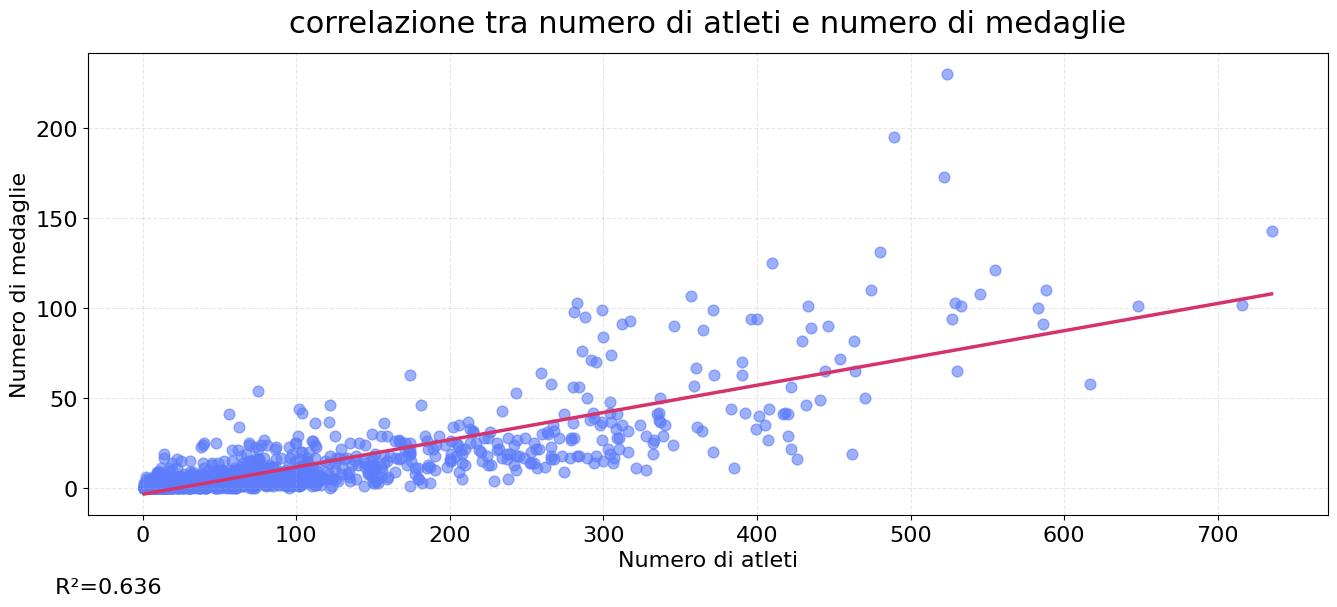

In [172]:
plt.figure(figsize=(16,6))
plt.scatter(num_athletes_medals_NOC_host["NumAthletes"], num_athletes_medals_NOC_host["NumMedals"], color="#5C7CFA", alpha=0.6, s=60)

x_vals=np.array([num_athletes_medals_NOC_host["NumAthletes"].min(), num_athletes_medals_NOC_host["NumAthletes"].max()])
y_vals=coeff_ang * x_vals + intercetta
plt.plot(x_vals, y_vals, color="#D6336C", linewidth=2.5)

plt.xlabel("Numero di atleti")
plt.ylabel("Numero di medaglie")
plt.figtext(0.1, -0.02, f" R²={r_value**2:.3f}", fontsize=16)
plt.grid(axis="both", alpha=0.3)
plt.title("correlazione tra numero di atleti e numero di medaglie", fontsize=22, pad=15)
plt.savefig("Relazione_Numero_atleti_vs_Numero_medaglie.png", dpi=150, bbox_inches="tight")
plt.show()


## VANTAGGIO DAL TIFO E DALLA FAMILIARITÀ CON GLI IMPIANTI?

In [173]:
avg_medals_athletes=num_athletes_medals_NOC_host.groupby("IsHost")["MedalsPerAthlete"].mean().reset_index()
avg_medals_athletes

,IsHost,MedalsPerAthlete
0,False,0.131786
1,True,0.133815


In [174]:
eff_host=num_athletes_medals_NOC_host[num_athletes_medals_NOC_host["IsHost"]==True]["MedalsPerAthlete"]
eff_nonhost=num_athletes_medals_NOC_host[num_athletes_medals_NOC_host["IsHost"]==False]["MedalsPerAthlete"]

t_stat3, p_value=sp.stats.ttest_ind(eff_host, eff_nonhost, equal_var=False)
print(f"p-value: {p_value:.5f}")

p-value: 0.90110


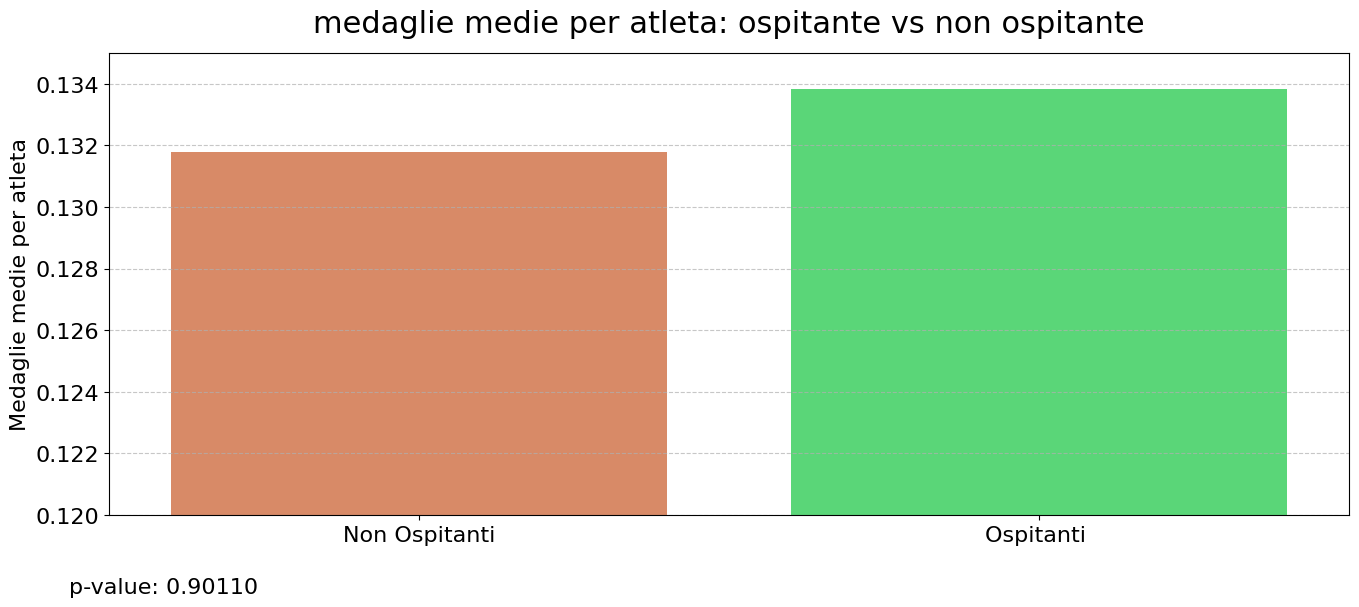

In [175]:
plt.figure(figsize=(16,6))
sns.barplot(x="IsHost", y="MedalsPerAthlete", hue="IsHost", data=avg_medals_athletes, palette=["#EB8354", "#46EA6D"], legend=False)
plt.ylim(0.12, 0.1350)
plt.xticks([0,1], ["Non Ospitanti", "Ospitanti "])
plt.ylabel("Medaglie medie per atleta")
plt.xlabel("")
plt.figtext(0.1, -0.02, f"p-value: {p_value:.5f}", fontsize=16)
plt.title("medaglie medie per atleta: ospitante vs non ospitante", fontsize=22, pad=15)
plt.savefig("Efficienza_atleti.png", dpi=150, bbox_inches="tight")
plt.show()


<div style="position:absolute; top:0; left:0; width:1280px; height:720px; display:flex; flex-direction:column; justify-content:center; padding:60px 80px; box-sizing:border-box; gap:60px;">
  <h4 style="font-size:35px; font-weight:bold; margin:0 0 12px 0;">CONCLUSIONI</h4>
  <div>
    <h4 style="font-size:35px; font-weight:bold; margin:0 0 12px 0;">C'É UN VANTAGGIO DA OSPITANTE?</h4>
    <ul style="font-size:25px; line-height:1.7; margin:0;">
      <li>Sì: le nazioni ospitanti vincono in media più medaglie rispetto alle proprie altre edizioni</li>
    </ul>
  </div>
  <div>
    <h4 style="font-size:28px; font-weight:bold; margin:0 0 12px 0;">DA COSA DERIVA IL VANTAGGIO?</h4>
    <ul style="font-size:24px; line-height:1.7; margin:0;">
      <li>Le nazioni ospitanti portano in media più del doppio degli atleti</li>
      <li>Il numero maggiore di atleti spiega il 64% della variabilità delle medaglie (R²=0.636)</li>
      <li>Altri fattori non legati alla familiarità con gli impianti o il numero di tifosi maggiore</li>
    </ul>
  </div>
</div>

# GRAZIE PER L'ATTENZIONE